In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error 

In [23]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [14]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
df.shape

(200, 4)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [17]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [18]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

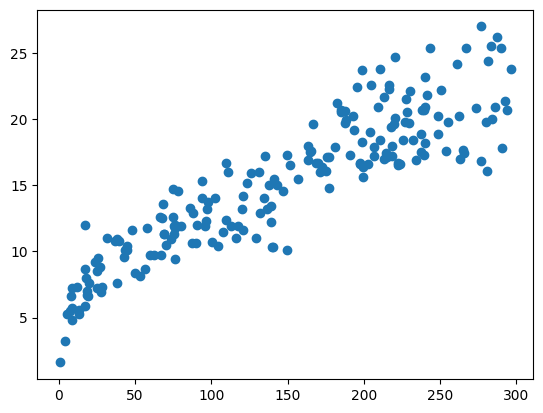

In [19]:
plt.scatter(df['TV'], df['Sales'])  

In [25]:
X = df.drop(columns = "Sales", axis =  1)
Y = df['Sales']

ler = LinearRegression()
ler.fit(X,Y)

pred_Y = ler.predict(X)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=40)
s = StandardScaler()
X_train = s.fit_transform(X_train)
X_test = s.transform(X_test)


ler = LinearRegression()
ler.fit(X_train, y_train)
y_pred = ler.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R-squared Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))




Mean Absolute Error: 1.5349470155728533
R-squared Score: 0.8477283412895043
Mean Squared Error: 4.3329956870703885


In [28]:
import pandas as pd 
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [29]:
X = df.drop(columns = "Sales", axis =  1)
Y = df['Sales']

In [30]:
X["dummy"] = 2*X["Radio"]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]   

c:\Users\PRIYANSHU\OneDrive\Desktop\MLTP\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [31]:
print(vif_data)

     feature       VIF
0         TV  2.486772
1      Radio       inf
2  Newspaper  3.055245
3      dummy       inf


In [32]:
#polynomial regression
X = df.drop(columns = "Sales", axis =  1)
Y = df['Sales']


In [33]:
from sklearn.preprocessing import PolynomialFeatures

p = PolynomialFeatures(degree=3)
poly_x = p.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(poly_x, Y, test_size=0.2, random_state=40)
s = StandardScaler()
X_train = s.fit_transform(X_train)
X_test = s.transform(X_test)


pr = LinearRegression()
pr.fit(X_train, y_train)
y_pred = pr.predict(X_test)
